## Anime Success Predictor 

So our goal will be to predict if an anime will be a top rated anime or not

our criterion will be \
success = 1  if score >= 8 \
success = 0  if score < 8 


In [539]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('anime-dataset-2023.csv')
df

,anime_id,Name,English name,Other name,Score,Genres,Synopsis,Type,Episodes,Aired,...,Studios,Source,Duration,Rating,Rank,Popularity,Favorites,Scored By,Members,Image URL
0,1,Cowboy Bebop,Cowboy Bebop,カウボーイビバップ,8.75,"Action, Award Winning, Sci-Fi","Crime is timeless. By the year 2071, humanity ...",TV,26.0,"Apr 3, 1998 to Apr 24, 1999",...,Sunrise,Original,24 min per ep,R - 17+ (violence & profanity),41.0,43,78525,914193.0,1771505,https://cdn.myanimelist.net/images/anime/4/196...
1,5,Cowboy Bebop: Tengoku no Tobira,Cowboy Bebop: The Movie,カウボーイビバップ 天国の扉,8.38,"Action, Sci-Fi","Another day, another bounty—such is the life o...",Movie,1.0,"Sep 1, 2001",...,Bones,Original,1 hr 55 min,R - 17+ (violence & profanity),189.0,602,1448,206248.0,360978,https://cdn.myanimelist.net/images/anime/1439/...
2,6,Trigun,Trigun,トライガン,8.22,"Action, Adventure, Sci-Fi","Vash the Stampede is the man with a $$60,000,0...",TV,26.0,"Apr 1, 1998 to Sep 30, 1998",...,Madhouse,Manga,24 min per ep,PG-13 - Teens 13 or older,328.0,246,15035,356739.0,727252,https://cdn.myanimelist.net/images/anime/7/203...
3,7,Witch Hunter Robin,Witch Hunter Robin,Witch Hunter ROBIN (ウイッチハンターロビン),7.25,"Action, Drama, Mystery, Supernatural",Robin Sena is a powerful craft user drafted in...,TV,26.0,"Jul 3, 2002 to Dec 25, 2002",...,Sunrise,Original,25 min per ep,PG-13 - Teens 13 or older,2764.0,1795,613,42829.0,111931,https://cdn.myanimelist.net/images/anime/10/19...
4,8,Bouken Ou Beet,Beet the Vandel Buster,冒険王ビィト,6.94,"Adventure, Fantasy, Supernatural",It is the dark century and the people are suff...,TV,52.0,"Sep 30, 2004 to Sep 29, 2005",...,Toei Animation,Manga,23 min per ep,PG - Children,4240.0,5126,14,6413.0,15001,https://cdn.myanimelist.net/images/anime/7/215...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24900,55731,Wu Nao Monu,UNKNOWN,无脑魔女,UNKNOWN,"Comedy, Fantasy, Slice of Life",No description available for this anime.,ONA,15.0,"Jul 4, 2023 to ?",...,UNKNOWN,Web manga,Unknown,PG-13 - Teens 13 or older,UNKNOWN,24723,0,UNKNOWN,0,https://cdn.myanimelist.net/images/anime/1386/...
24901,55732,Bu Xing Si: Yuan Qi,Blader Soul,捕星司·源起,UNKNOWN,"Action, Adventure, Fantasy",No description available for this anime.,ONA,18.0,"Jul 27, 2023 to ?",...,UNKNOWN,Web novel,Unknown,PG-13 - Teens 13 or older,0.0,0,0,UNKNOWN,0,https://cdn.myanimelist.net/images/anime/1383/...
24902,55733,Di Yi Xulie,The First Order,第一序列,UNKNOWN,"Action, Adventure, Fantasy, Sci-Fi",No description available for this anime.,ONA,16.0,"Jul 19, 2023 to ?",...,UNKNOWN,Web novel,Unknown,PG-13 - Teens 13 or older,0.0,0,0,UNKNOWN,0,https://cdn.myanimelist.net/images/anime/1130/...
24903,55734,Bokura no Saishuu Sensou,UNKNOWN,僕らの最終戦争,UNKNOWN,UNKNOWN,A music video for the song Bokura no Saishuu S...,Music,1.0,"Apr 23, 2022",...,UNKNOWN,Original,3 min,PG-13 - Teens 13 or older,0.0,0,0,UNKNOWN,0,https://cdn.myanimelist.net/images/anime/1931/...


In [540]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24905 entries, 0 to 24904
Data columns (total 24 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   anime_id      24905 non-null  int64
 1   Name          24905 non-null  str  
 2   English name  24905 non-null  str  
 3   Other name    24905 non-null  str  
 4   Score         24905 non-null  str  
 5   Genres        24905 non-null  str  
 6   Synopsis      24905 non-null  str  
 7   Type          24905 non-null  str  
 8   Episodes      24905 non-null  str  
 9   Aired         24905 non-null  str  
 10  Premiered     24905 non-null  str  
 11  Status        24905 non-null  str  
 12  Producers     24905 non-null  str  
 13  Licensors     24905 non-null  str  
 14  Studios       24905 non-null  str  
 15  Source        24905 non-null  str  
 16  Duration      24905 non-null  str  
 17  Rating        24905 non-null  str  
 18  Rank          24905 non-null  str  
 19  Popularity    24905 non-null  int64


## EDA

so i think the relevent features will be 

- members (number of ppl added it to their anime list)
- favorites
- scored_by (no of ppl rated the show) 
- genre
- type
- episodes
- source
- studio

### Score Distribution

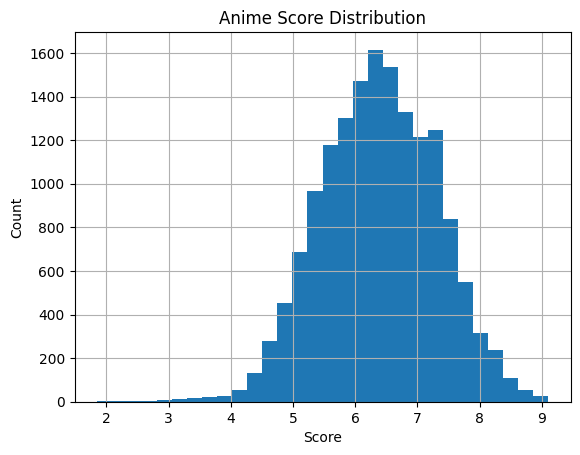

In [541]:

df["Score"] = pd.to_numeric(df["Score"], errors="coerce")
df = df.dropna(subset=["Score"])

df["Score"].hist(bins=30)

plt.title("Anime Score Distribution")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()

so most anime are in the range of 5 to 7.5 \
not a lot of anime are above 8 

### Anime type Distribution

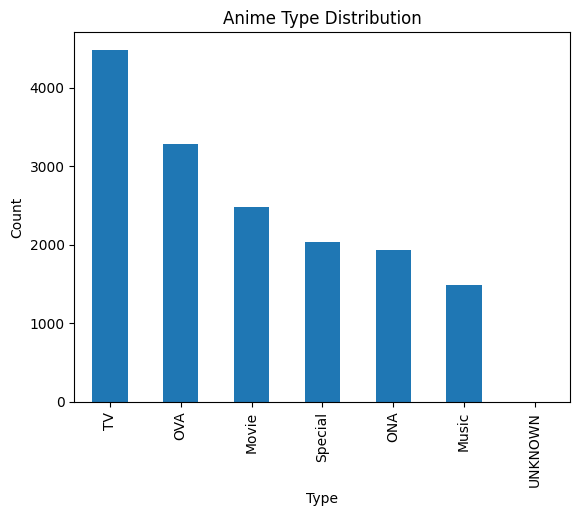

In [542]:
df["Type"].value_counts().plot(kind="bar")

plt.title("Anime Type Distribution")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

most of them are obviously TV as expected followed by OVAs, Movie, Special is surprisingly high in number i was definitely not expecting so many special.

### Episode Distribution

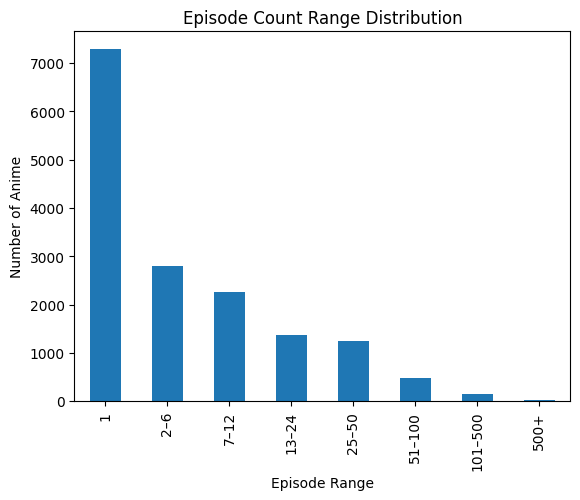

In [543]:
df["Episodes"] = pd.to_numeric(df["Episodes"], errors="coerce")

bins = [0, 1, 6, 12, 24, 50, 100, 500, 2000]
labels = [
    "1",
    "2–6",
    "7–12",
    "13–24",
    "25–50",
    "51–100",
    "101–500",
    "500+"
]

df["episode_range"] = pd.cut(df["Episodes"], bins=bins, labels=labels)
df["episode_range"].value_counts().sort_index().plot(kind="bar")

plt.title("Episode Count Range Distribution")
plt.xlabel("Episode Range")
plt.ylabel("Number of Anime")
plt.show()

oh well \
i was definitely not expecting so manyyyy 1 episode anime. But it makes sense as it mainly consists of movies, some specials, and some small 1 ep works (and a lot of uh questionable anime).
2-6 is also surprisingly high in number.


### EPs vs Scores

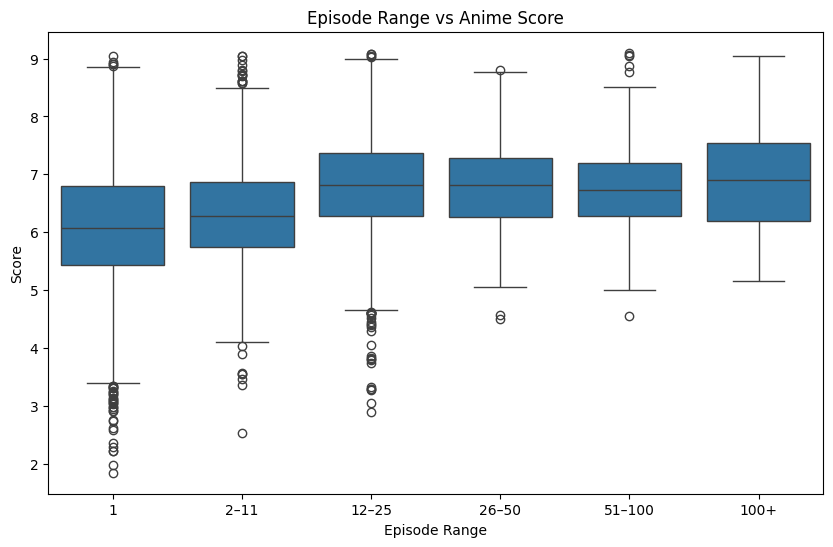

In [544]:
df["Episodes"] = pd.to_numeric(df["Episodes"], errors="coerce")
df["Score"] = pd.to_numeric(df["Score"], errors="coerce")

df = df.dropna(subset=["Episodes", "Score"])
bins = [0, 1, 11, 25, 50, 100, 2000]

labels = [
    "1",
    "2–11",
    "12–25",
    "26–50",
    "51–100",
    "100+"
]

df["episode_range"] = pd.cut(df["Episodes"], bins=bins, labels=labels)
plt.figure(figsize=(10,6))

sns.boxplot(x="episode_range", y="Score", data=df)

plt.title("Episode Range vs Anime Score")
plt.xlabel("Episode Range")
plt.ylabel("Score")

plt.show()

now here as expected anime with 12 or more episodes have higher average scores as thats the range where most of the popular works are present

### Top Genres

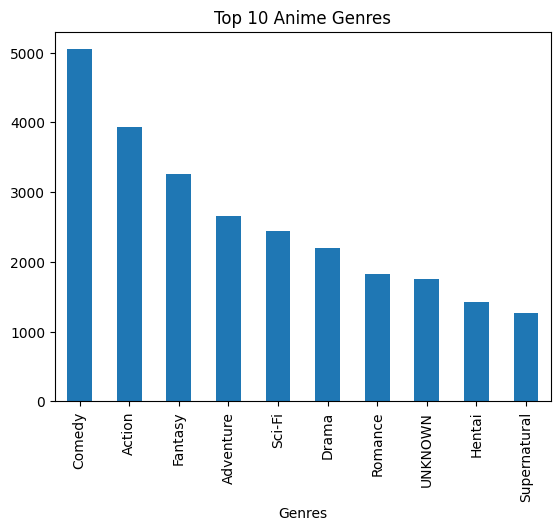

In [545]:
genres = df["Genres"].str.split(", ")
genres = genres.explode()

genres.value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Anime Genres")
plt.show()

here i though action, fantasy will take top spots but its comedy 
ppl love comedy lol \ 
but yeah most anime have multiple genre tags so it makes sense 

### popularity vs score

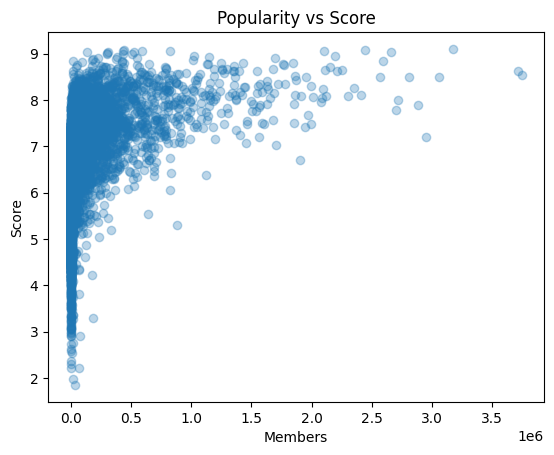

In [546]:
plt.scatter(df["Members"], df["Score"], alpha=0.3)

plt.xlabel("Members")
plt.ylabel("Score")
plt.title("Popularity vs Score")
plt.show()

yeah so popular anime are watched by more number of people as expected

### Top Studios

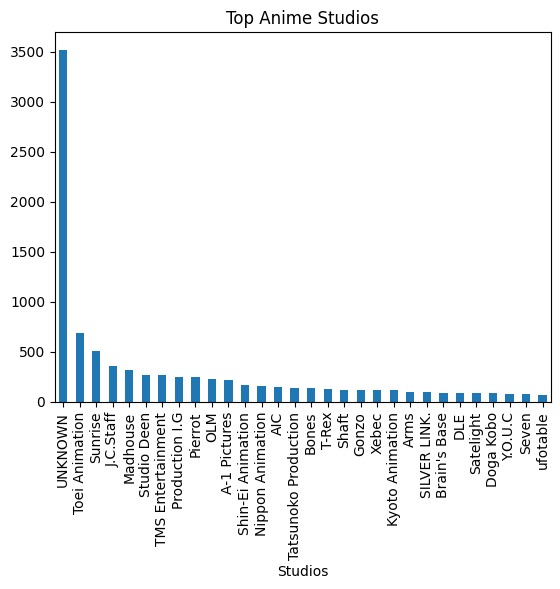

In [547]:
df["Studios"].value_counts().head(30).plot(kind="bar")

plt.title("Top Anime Studios")
plt.show()

Older Studios have more number of anime as expected

### Studios vs Average Scores of their anime

i am really excited to know this 

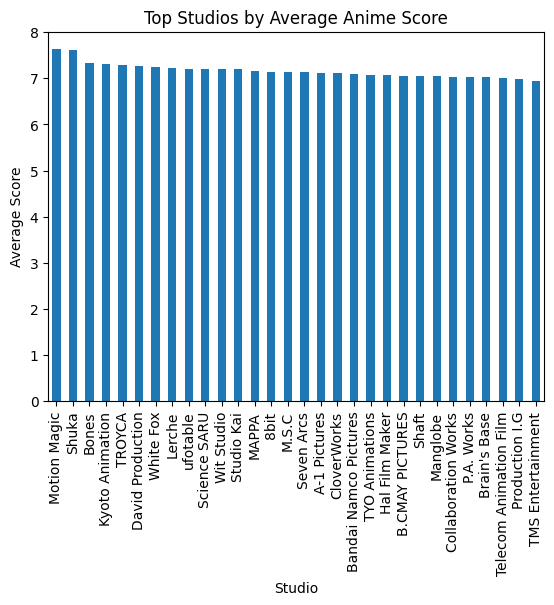

In [548]:
df["Score"] = pd.to_numeric(df["Score"], errors="coerce")
df = df.dropna(subset=["Score"])

studios = df["Studios"].str.split(", ")
studios = studios.explode()

studio_scores = df.copy()
studio_scores["Studios"] = studio_scores["Studios"].str.split(", ")
studio_scores = studio_scores.explode("Studios")

avg_scores = studio_scores.groupby("Studios")["Score"].mean()
avg_scores = avg_scores.sort_values(ascending=False)

studio_counts = studio_scores["Studios"].value_counts()

valid_studios = studio_counts[studio_counts > 10].index

avg_scores = studio_scores[studio_scores["Studios"].isin(valid_studios)] \
                .groupby("Studios")["Score"].mean() \
                .sort_values(ascending=False)

avg_scores.head(30).plot(kind="bar")

plt.title("Top Studios by Average Anime Score")
plt.xlabel("Studio")
plt.ylabel("Average Score")

plt.show()


oh the numbers are interesting 
first of all we filtered all studio with less than 10 anime productions 
so now we have proper studios and here i was definitely not expectiong Motion Magic ????? to be at the top, some things to notice is some newer studios have higher average scores than some old studios (probably becuase older animations didnt get a very high scores)

### correlation matrix


In [549]:
cols = [
    "Score",
    "Episodes",
    "Members",
    "Favorites",
    "Popularity",
    "Rank",
    "Scored By"
]

numerical = df[cols]


In [550]:
numerical = numerical.apply(pd.to_numeric, errors="coerce")
numerical = numerical.dropna()

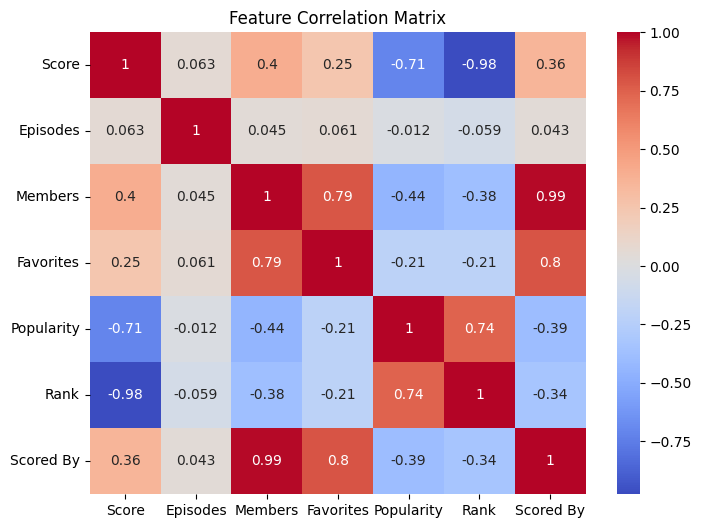

In [551]:
plt.figure(figsize=(8,6))
sns.heatmap(numerical.corr(), annot=True, cmap="coolwarm")

plt.title("Feature Correlation Matrix")
plt.show()

- Score and Rank have a very strong negative correlation (-0.98), which makes sense.
- Members and Scored By show an extremely strong positive correlation (0.99), this shows that anime with more viewers tend to have more users rating them obvisously.
- Members and Favorites also have a strong positive correlation (0.79), similarly to members and scoredby.
- Score and Members show a moderate positive correlation (0.40), this shows that anime with more viewers tend to receive slightly higher scores.
- Episodes have very weak correlation with most variables, because the number of episodes alone does not strongly influence anime ratings.

Overall, engagement-related features such as Members, Favorites, and Scored By are strongly related to each other, while Rank is highly dependent on Score because rank is decided by scores.

## Feature Engineering and Data cleaning

In [552]:
df["Score"] = pd.to_numeric(df["Score"], errors="coerce")
df["Favorites"] = pd.to_numeric(df["Favorites"], errors="coerce")
df["Episodes"] = pd.to_numeric(df["Episodes"], errors="coerce")
df["Members"] = pd.to_numeric(df["Members"], errors="coerce")
df["Favorites"] = pd.to_numeric(df["Favorites"], errors="coerce")
df["Episodes"] = pd.to_numeric(df["Episodes"], errors="coerce")


In [553]:
df = df.dropna(subset=["Score"])
df["success"] = (df["Score"] >= 8).astype(int)

ok we can get a ratio of fav/members which will be a very good feature

In [554]:
df["fav/members_ratio"] = df["Favorites"] / df["Members"]
df["fav/members_ratio"] = df["fav/members_ratio"].fillna(0)

In [555]:
df["Episodes"] = df["Episodes"].fillna(df["Episodes"].median())
df["Genres"] = df["Genres"].fillna("")

### encoding

In [556]:
type_encoded = pd.get_dummies(df["Type"], prefix="type")
df = pd.concat([df, type_encoded], axis=1)

source_encoded = pd.get_dummies(df["Source"], prefix="source")
df = pd.concat([df, source_encoded], axis=1)

In [557]:
genres = df["Genres"].str.get_dummies(sep=", ")
df = pd.concat([df, genres], axis=1)

we will take log ok members as that number is very big

In [558]:
df["members_log"] = np.log1p(df["Members"]) 

In [559]:
features = [
    "members_log",
    "fav/members_ratio",
    "Episodes"
]

features += list(type_encoded.columns)
features += list(source_encoded.columns)
features += list(genres.columns)

X = df[features]

y = df["success"]

## train test split

In [560]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [561]:
X_train = X_train.astype(float).values
X_test = X_test.astype(float).values

y_train = y_train.astype(float).values
y_test = y_test.astype(float).values

### Model

## Sigmoid Function

In [562]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [563]:
def train_logistic(X, y, lr=0.01, epochs=1000):

    m, n = X.shape

    weights = np.zeros(n)
    bias = 0

    for _ in range(epochs):

        z = np.dot(X, weights) + bias
        predictions = sigmoid(z)

        dw = (1/m) * np.dot(X.T, (predictions - y))
        db = (1/m) * np.sum(predictions - y)

        weights -= lr * dw
        bias -= lr * db

    return weights, bias

In [564]:
weights, bias = train_logistic(X_train, y_train)

In [565]:
def predict(X, weights, bias):

    z = np.dot(X, weights) + bias

    probs = sigmoid(z)

    return (probs >= 0.5).astype(int)

In [566]:
preds = predict(X_test, weights, bias)

accuracy = np.mean(preds == y_test)

print("Accuracy:", accuracy)

Accuracy: 0.9583466837552067


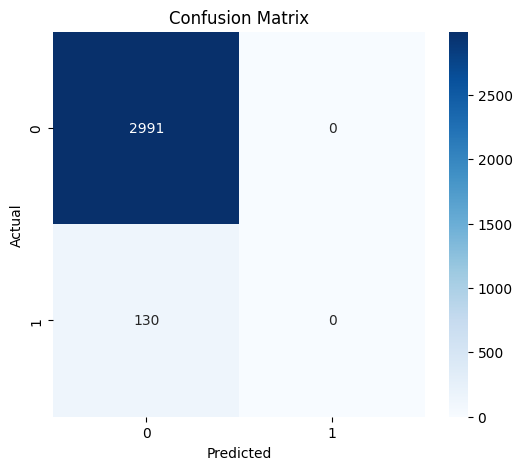

In [567]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()
